# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Jordan Sebastian Simatupang | 5054251038 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
data = pd.read_csv("data.csv")
data.columns = data.columns.str.strip()

print("Ukuran dataset:", data.shape)
print("\nTipe data:")
data.info()

print("\nStatistik deskriptif:")
display(data.describe().T)

print("\nJumlah missing value (hanya kolom yang punya missing value):")
missing = data.isnull().sum()
print(missing[missing > 0])

print("\nJumlah data duplikat:", data.duplicated().sum())

Ukuran dataset: (569, 33)

Tipe data:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14 

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01



Jumlah missing value (hanya kolom yang punya missing value):
Unnamed: 32    569
dtype: int64

Jumlah data duplikat: 0


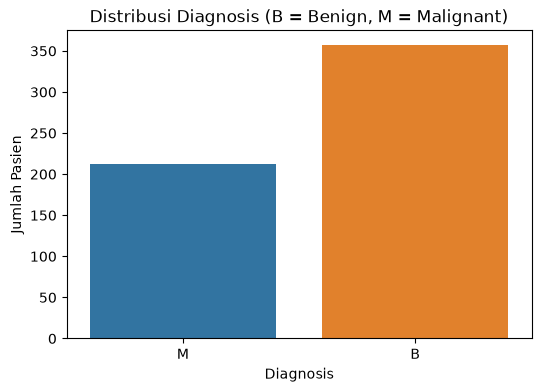

diagnosis
B    357
M    212
Name: count, dtype: int64

Persentase:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="diagnosis", hue="diagnosis", legend=False)
plt.title("Distribusi Diagnosis (B = Benign, M = Malignant)")
plt.xlabel("Diagnosis")
plt.ylabel("Jumlah Pasien")
plt.show()

print(data["diagnosis"].value_counts())
print("\nPersentase:")
print(data["diagnosis"].value_counts(normalize=True) * 100)

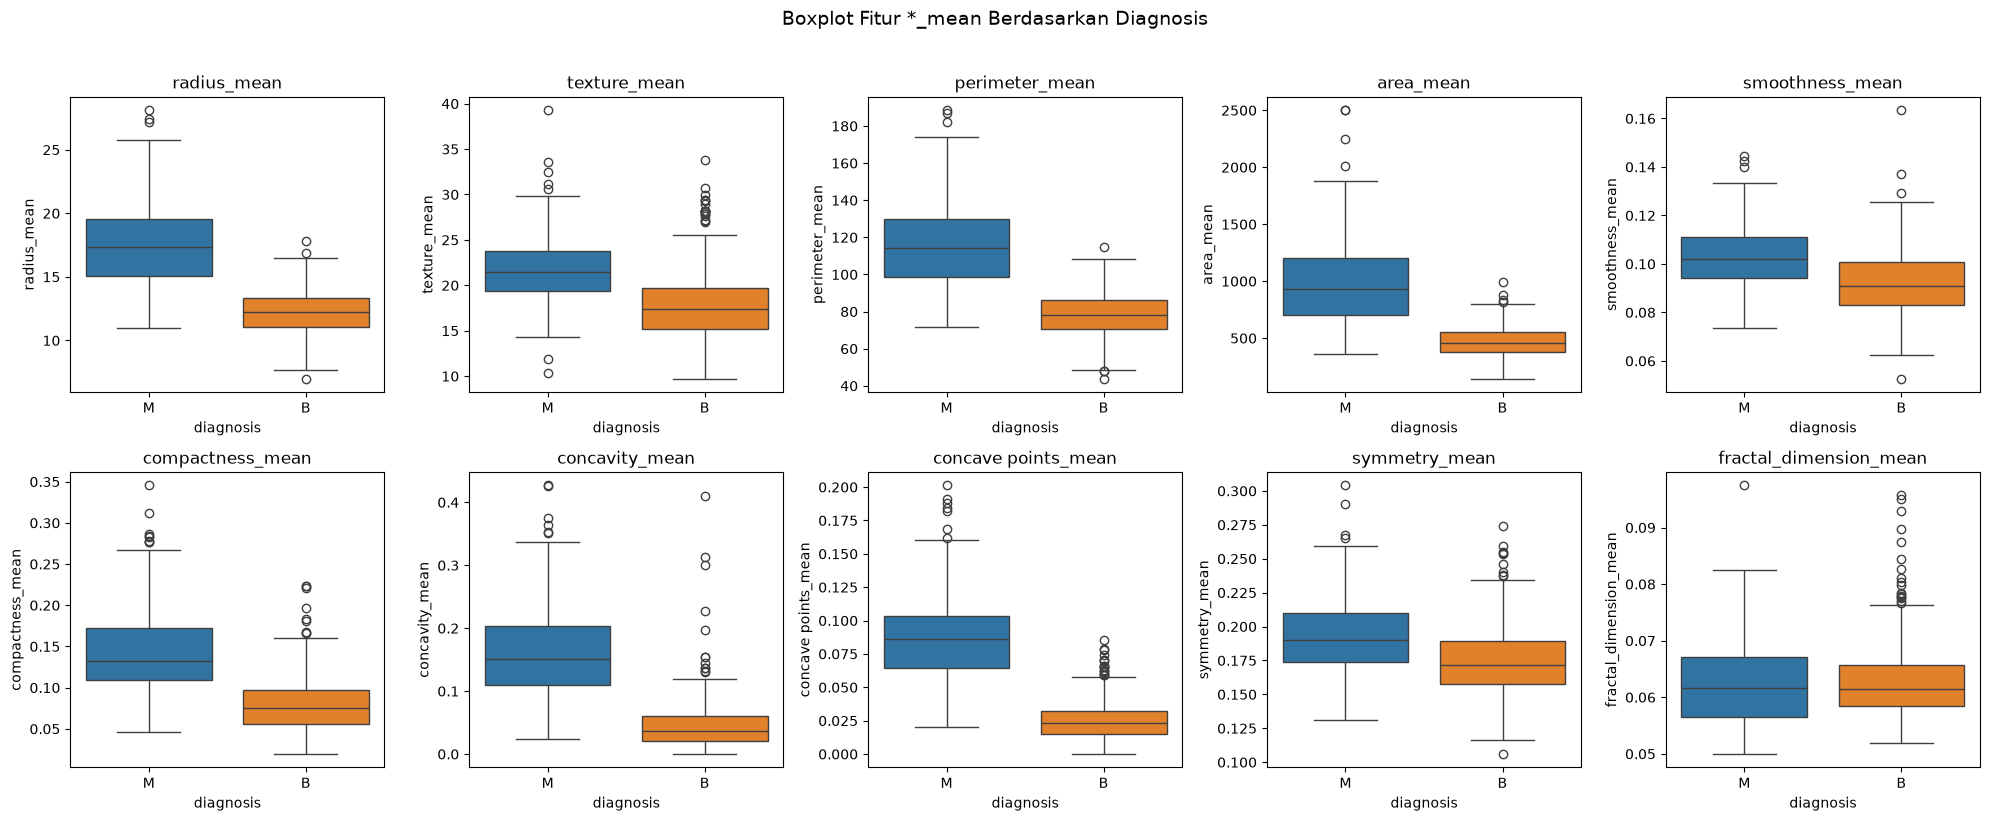

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas (linear) antar kelas, atau justru tumpang tindih.
fitur_mean = [kolom for kolom in data.columns if kolom.endswith("_mean")]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for ax, kolom in zip(axes, fitur_mean):
    sns.boxplot(data=data, x="diagnosis", y=kolom, hue="diagnosis", legend=False, ax=ax)
    ax.set_title(kolom)
plt.suptitle("Boxplot Fitur *_mean Berdasarkan Diagnosis", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

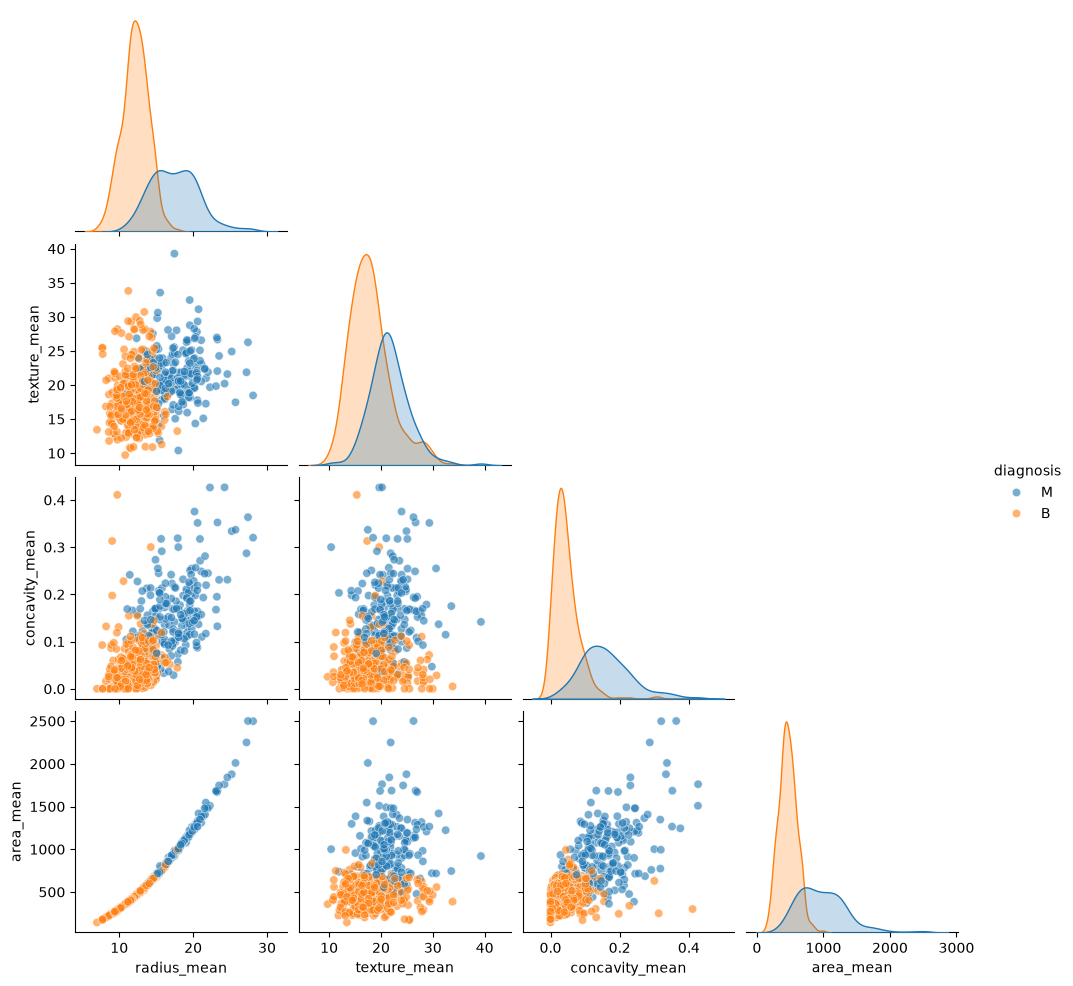

In [5]:
fitur_pair = ["radius_mean", "texture_mean", "concavity_mean", "area_mean"]
sns.pairplot(data[fitur_pair + ["diagnosis"]], hue="diagnosis", corner=True, plot_kws={"alpha": 0.6})
plt.show()

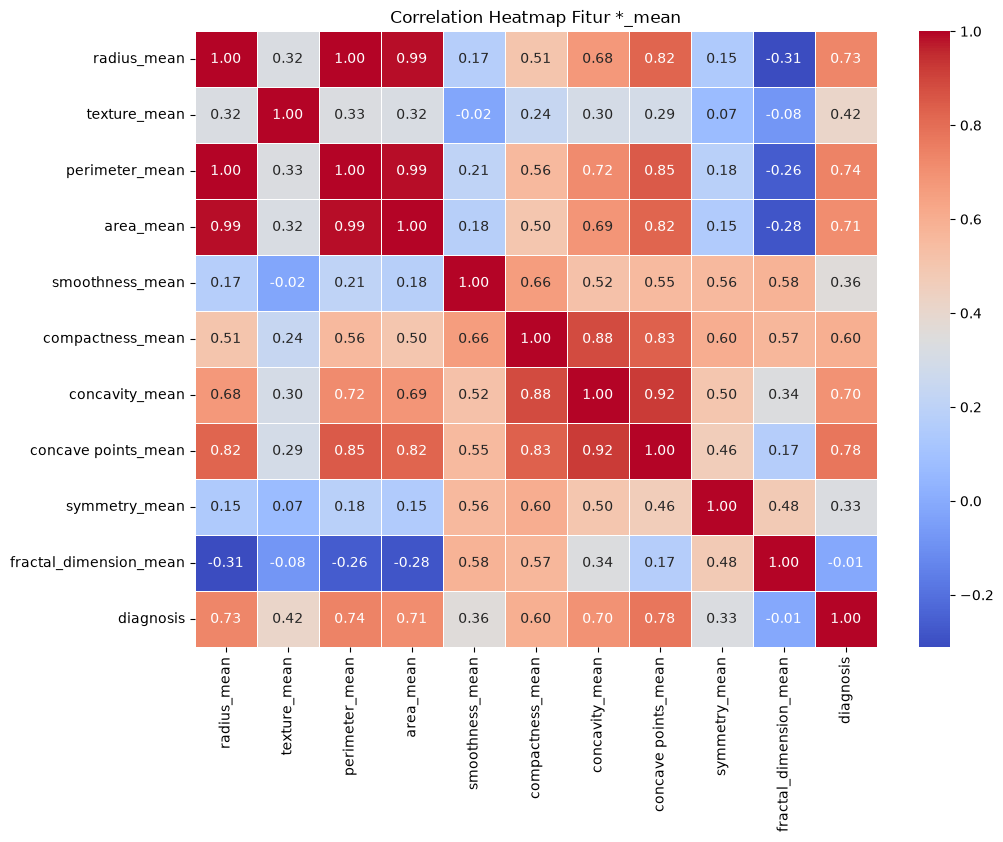

In [6]:
corr_data = data[fitur_mean].copy()
corr_data["diagnosis"] = data["diagnosis"].map({"B": 0, "M": 1})

plt.figure(figsize=(11, 8))
sns.heatmap(corr_data.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap Fitur *_mean")
plt.show()

# 2. Preprocessing

In [7]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
data = data.drop(columns=["Unnamed: 32", "id"])

print("Sisa missing value:", data.isnull().sum().sum())
print("Ukuran dataset setelah dibersihkan:", data.shape)

Sisa missing value: 0
Ukuran dataset setelah dibersihkan: (569, 31)


In [8]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
data["diagnosis"] = data["diagnosis"].map({"B": 0, "M": 1})

print(data["diagnosis"].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [9]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = data.drop(columns=["diagnosis"])
y = data["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("\nProporsi kelas malignant (train):", round(y_train.mean(), 4))
print("Proporsi kelas malignant (test) :", round(y_test.mean(), 4))

Ukuran X_train: (455, 30)
Ukuran X_test : (114, 30)

Proporsi kelas malignant (train): 0.3736
Proporsi kelas malignant (test) : 0.3684


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [10]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Ukuran X_train setelah scaling:", X_train_scaled.shape)
print("Ukuran X_test setelah scaling :", X_test_scaled.shape)
print("\nRata-rata train set setelah scaling (harusnya ~0):", X_train_scaled.mean().abs().max().round(6))

Ukuran X_train setelah scaling: (455, 30)
Ukuran X_test setelah scaling : (114, 30)

Rata-rata train set setelah scaling (harusnya ~0): 0.0


# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [11]:
# Inisialisasi dan latih model SVC dengan kernel='linear' menggunakan train set (yang sudah discaling).
C_dasar = 1.0

model_linear = SVC(kernel="linear", C=C_dasar, random_state=42)
model_linear.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_linear = model_linear.predict(X_test_scaled)

print("Hasil prediksi (10 pertama):", y_pred_linear[:10])
print("Akurasi test (Linear):", round(accuracy_score(y_test, y_pred_linear) * 100, 2), "%")

Hasil prediksi (10 pertama): [0 1 0 0 0 0 1 0 0 0]
Akurasi test (Linear): 96.49 %


## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [13]:
# Inisialisasi dan latih model SVC dengan kernel='rbf' menggunakan train set.
# Gunakan nilai hyperparameter lain (C) yang sama seperti model Linear di atas, agar perbandingan adil.
model_rbf = SVC(kernel="rbf", C=C_dasar, gamma="scale", random_state=42)
model_rbf.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [14]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_rbf = model_rbf.predict(X_test_scaled)

print("Hasil prediksi (10 pertama):", y_pred_rbf[:10])
print("Akurasi test (RBF):", round(accuracy_score(y_test, y_pred_rbf) * 100, 2), "%")

Hasil prediksi (10 pertama): [0 1 0 0 0 0 1 0 0 0]
Akurasi test (RBF): 97.37 %


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [15]:
# Latih beberapa model SVC (kernel RBF) dengan variasi nilai C,
# misalnya 0.01, 0.1, 1, 10, 100.
# Gunakan gamma='scale' atau nilai gamma tetap agar perbandingan fokus pada pengaruh C.
nilai_C = [0.01, 0.1, 1, 10, 100]

models_C = {}
for C in nilai_C:
    model = SVC(kernel="rbf", C=C, gamma="scale", random_state=42)
    model.fit(X_train_scaled, y_train)
    models_C[C] = model

In [16]:
# Hitung akurasi pada train set dan test set untuk setiap nilai C yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
hasil_C = []

for C, model in models_C.items():
    train_accuracy = accuracy_score(y_train, model.predict(X_train_scaled)) * 100
    test_accuracy = accuracy_score(y_test, model.predict(X_test_scaled)) * 100

    hasil_C.append({
        "C": C,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Selisih (Train - Test)": train_accuracy - test_accuracy
    })

hasil_C_df = pd.DataFrame(hasil_C)
display(hasil_C_df)

,C,Train Accuracy,Test Accuracy,Selisih (Train - Test)
0,0.01,62.637363,63.157895,-0.520532
1,0.10,95.384615,94.736842,0.647773
2,1.00,98.681319,97.368421,1.312898
3,10.00,98.901099,97.368421,1.532678
4,100.00,100.000000,96.491228,3.508772


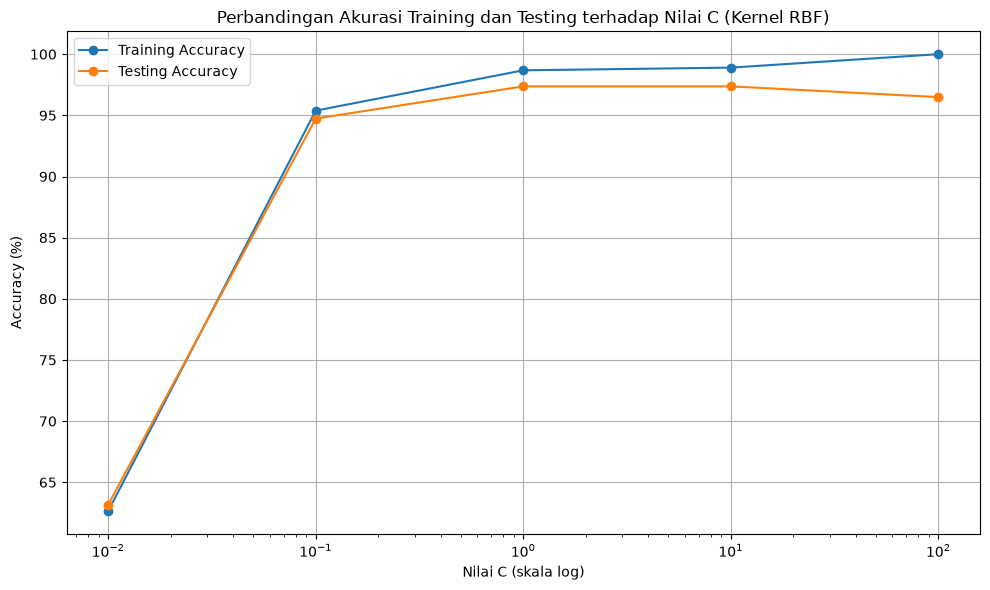

In [17]:
# Plot grafik akurasi training vs testing terhadap nilai C (gunakan sumbu x logaritmik) dalam satu chart.
# Amati pada nilai C berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(10, 6))

plt.plot(hasil_C_df["C"], hasil_C_df["Train Accuracy"], marker="o", label="Training Accuracy")
plt.plot(hasil_C_df["C"], hasil_C_df["Test Accuracy"], marker="o", label="Testing Accuracy")

plt.xscale("log")
plt.title("Perbandingan Akurasi Training dan Testing terhadap Nilai C (Kernel RBF)")
plt.xlabel("Nilai C (skala log)")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [18]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
hasil_eval = []

for nama, y_pred in [("Linear", y_pred_linear), ("RBF", y_pred_rbf)]:
    hasil_eval.append({
        "Model": nama,
        "Accuracy": accuracy_score(y_test, y_pred) * 100,
        "Precision": precision_score(y_test, y_pred) * 100,
        "Recall": recall_score(y_test, y_pred) * 100,
        "F1-Score": f1_score(y_test, y_pred) * 100
    })

tabel_evaluasi = pd.DataFrame(hasil_eval).set_index("Model").round(2)
display(tabel_evaluasi)

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Linear,96.49,100.0,90.48,95.0
RBF,97.37,100.0,92.86,96.3


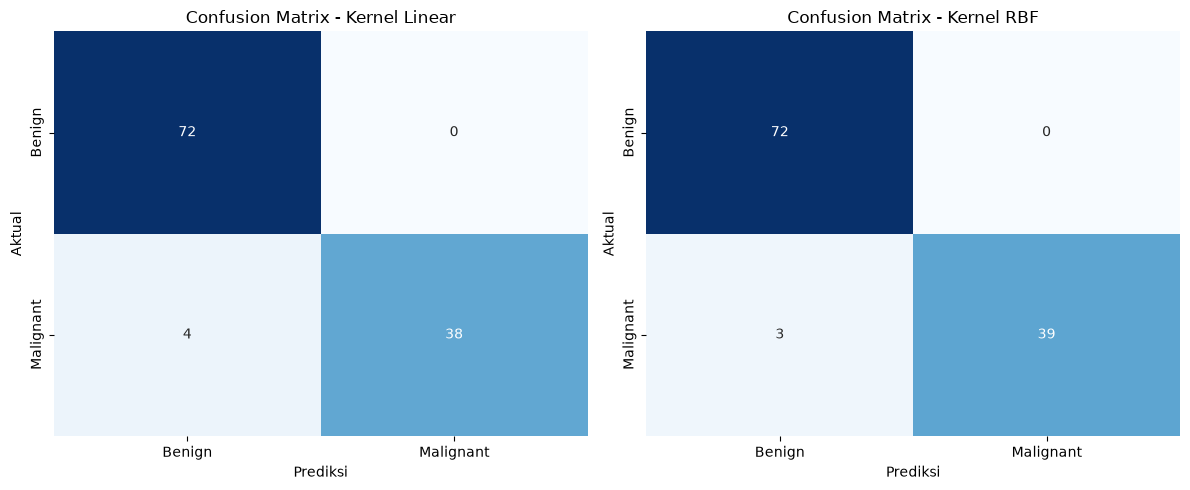

In [19]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, nama, y_pred in zip(axes, ["Linear", "RBF"], [y_pred_linear, y_pred_rbf]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"]
    )
    ax.set_title(f"Confusion Matrix - Kernel {nama}")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")

plt.tight_layout()
plt.show()

In [20]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik (atribut model.support_vectors_ atau model.n_support_).
# Bandingkan jumlah support vectors antara model Linear dan RBF.
akurasi_linear = accuracy_score(y_test, y_pred_linear)
akurasi_rbf = accuracy_score(y_test, y_pred_rbf)

if akurasi_rbf > akurasi_linear:
    nama_terbaik, model_terbaik = "RBF", model_rbf
else:
    nama_terbaik, model_terbaik = "Linear", model_linear
print("Model dengan performa terbaik (akurasi test):", nama_terbaik)

hasil_sv = pd.DataFrame({
    "Model": ["Linear", "RBF"],
    "SV Benign": [model_linear.n_support_[0], model_rbf.n_support_[0]],
    "SV Malignant": [model_linear.n_support_[1], model_rbf.n_support_[1]],
    "Total SV": [len(model_linear.support_vectors_), len(model_rbf.support_vectors_)],
    "% dari Data Train": [
        len(model_linear.support_vectors_) / len(X_train_scaled) * 100,
        len(model_rbf.support_vectors_) / len(X_train_scaled) * 100
    ]
}).set_index("Model").round(2)
display(hasil_sv)

Model dengan performa terbaik (akurasi test): RBF


,SV Benign,SV Malignant,Total SV,% dari Data Train
Model,,,,
Linear,19,19,38,8.35
RBF,50,57,107,23.52


Variansi yang dijelaskan 2 komponen PCA: 63.14 %


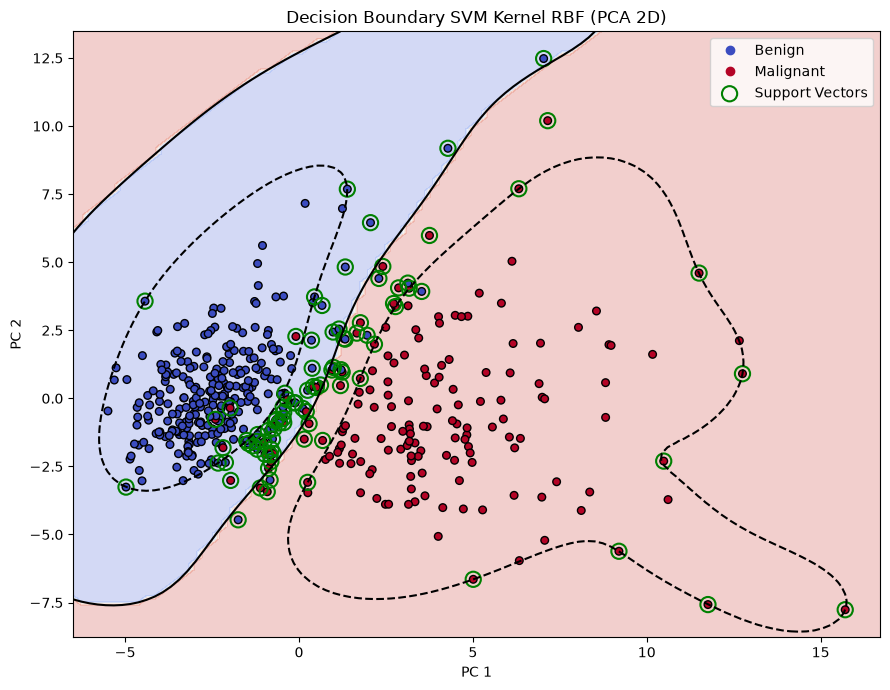

In [21]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("Variansi yang dijelaskan 2 komponen PCA:", round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

params = {"kernel": nama_terbaik.lower(), "C": C_dasar, "random_state": 42}
if nama_terbaik == "RBF":
    params["gamma"] = "scale"
model_2d = SVC(**params)
model_2d.fit(X_train_pca, y_train)

fig, ax = plt.subplots(figsize=(9, 7))

DecisionBoundaryDisplay.from_estimator(
    model_2d, X_train_pca, response_method="predict",
    cmap="coolwarm", alpha=0.25, ax=ax
)
DecisionBoundaryDisplay.from_estimator(
    model_2d, X_train_pca, response_method="decision_function",
    plot_method="contour", levels=[-1, 0, 1],
    colors="k", linestyles=["--", "-", "--"], ax=ax
)

scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap="coolwarm", edgecolors="k", s=30)
ax.scatter(
    model_2d.support_vectors_[:, 0], model_2d.support_vectors_[:, 1],
    s=120, facecolors="none", edgecolors="green", linewidths=1.5, label="Support Vectors"
)
ax.set_title(f"Decision Boundary SVM Kernel {nama_terbaik} (PCA 2D)")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
handles, _ = scatter.legend_elements()
ax.legend(handles + ax.get_legend_handles_labels()[0], ["Benign", "Malignant", "Support Vectors"])
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa SVM dengan kernel Linear vs RBF. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian, dikaitkan dengan bentuk sebaran data pada EDA?
- Jelaskan temuan dari eksperimen regularisasi (nilai `C`). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Bandingkan jumlah support vectors antara model Linear dan RBF. Apa hubungan jumlah support vectors dengan kompleksitas batas keputusan yang terbentuk?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

# 5. Analisis Hasil Eksperimen

### 5.1 Perbandingan Performa Kernel Linear vs RBF & Analisis EDA

Pengujian dilakukan pada dataset *Breast Cancer Wisconsin* (114 data uji):

| Metrik Evaluasi | Kernel Linear ($C = 1.0$) | Kernel RBF ($C = 1.0, \gamma = \text{'scale'}$) |
| :--- | :---: | :---: |
| Accuracy | 96,49% | 97,37% |
| Precision | 100,00% | 100,00% |
| Recall | 90,48% | 92,86% |
| F1-Score | 95,00% | 96,30% |

* **Perbedaan performa:**
  Hasil kedua kernel **tidak berbeda signifikan**. Kernel RBF unggul 0,88% pada akurasi, yang setara **1 sampel** (111 vs 110 benar dari 114), dan 2,38% pada recall, yang setara **1 pasien malignant** (39 vs 38 terdeteksi dari 42). Selisih sekecil ini bisa berasal dari pembagian data dan belum cukup untuk menyatakan satu kernel lebih baik. Kedua kernel menghasilkan *Precision* 100%, artinya tidak ada *false positive* (tumor jinak yang salah dideteksi ganas).

* **Kesalahan yang tersisa:**
  Seluruh kesalahan kedua model adalah *false negative*, yaitu **4 kasus malignant terlewat pada Linear dan 3 pada RBF**. Pada diagnosis kanker, kesalahan jenis ini yang paling berisiko, sehingga recall lebih penting dipantau daripada akurasi.

* **Keterkaitan dengan distribusi data (EDA):**
  Pada pairplot (`radius_mean`, `texture_mean`, `concavity_mean`, `area_mean`) dan boxplot fitur `*_mean`, kelas Benign dan Malignant **sebagian besar sudah terpisah**, terutama pada `radius_mean`, `concavity_mean`, dan `area_mean`. Namun masih ada **daerah tumpang-tindih**, misalnya pada `texture_mean` dan pada bagian bawah sebaran `radius_mean`/`area_mean`. Karena itu data **cukup terpisah secara linear dengan sedikit overlap**, bukan terpisah sempurna. Dukungan terkuat atas hal ini adalah akurasi model Linear yang sudah 96,49%: bidang pemisah lurus sudah cukup baik, sehingga kernel RBF yang lebih fleksibel hanya memberi peningkatan marginal.

---

### 5.2 Pengaruh Parameter $C$ dan Gejala Overfitting

Pengujian pada Kernel RBF ($\gamma = \text{'scale'}$) dengan $C \in \{0{,}01, 0{,}1, 1, 10, 100\}$:

| Nilai $C$ | Train Accuracy | Test Accuracy | Selisih (Train − Test) | Evaluasi |
| :---: | :---: | :---: | :---: | :--- |
| 0,01 | 62,64% | 63,16% | −0,52% | *Underfitting* |
| 0,10 | 95,38% | 94,74% | 0,65% | Cukup baik |
| 1,00 | 98,68% | 97,37% | 1,31% | Test accuracy tertinggi |
| 10,00 | 98,90% | 97,37% | 1,53% | Test accuracy tertinggi (setara $C=1$) |
| 100,00 | 100,00% | 96,49% | 3,51% | **Indikasi overfitting** |

* **Underfitting pada $C = 0{,}01$:**
  Akurasi training 62,64% sama dengan proporsi kelas benign pada data training (1 − 0,3736 ≈ 62,64%). Artinya model **hanya memprediksi semua data sebagai benign**. Penalti kesalahan yang terlalu lemah membuat margin terlalu lebar sehingga model gagal mempelajari pola.

* **Titik mulai overfitting:**
  Gejala overfitting mulai terlihat pada **$C = 100$**. Perlu dicatat bahwa penurunan akurasi testing dari 97,37% ke 96,49% hanya setara **1 sampel** dari 114, sehingga ini lebih tepat disebut *indikasi* daripada bukti kuat. Dukungan yang lebih kuat datang dari pola gap training–testing.

* **Ciri pada grafik akurasi:**
  1. Akurasi *training* mencapai **100%** pada $C = 100$. Penalti kesalahan yang sangat besar memaksa model mengklasifikasikan semua sampel training dengan benar, termasuk titik yang sulit atau berupa *outlier*.
  2. Akurasi *testing* tidak ikut naik: stagnan di 97,37% pada $C = 1$ dan $C = 10$, lalu turun ke 96,49% pada $C = 100$.
  3. *Gap* training–testing melebar terus dari 0,65% ($C=0{,}1$) ke 1,31% ($C=1$), 1,53% ($C=10$), dan 3,51% ($C=100$). Pola kurva training terus naik sementara kurva testing mendatar lalu turun inilah ciri khas overfitting.

* **Catatan:** Pemilihan $C=1$ sebagai nilai terbaik berdasarkan test set. Untuk keputusan yang lebih andal sebaiknya dipakai validation set atau cross-validation. Pada eksperimen ini hanya $C$ yang divariasikan, sedangkan $\gamma$ ditetapkan `'scale'`.

---

### 5.3 Jumlah Support Vectors dan Kompleksitas Batas Keputusan

| Kernel | SV Benign | SV Malignant | Total SV | % dari Data Train (455) |
| :--- | :---: | :---: | :---: | :---: |
| Linear | 19 | 19 | 38 | 8,35% |
| RBF | 50 | 57 | 107 | 23,52% |

* **Hubungan dengan kompleksitas batas keputusan:**
  * **Kernel Linear (38 SV / 8,35%):** Batas keputusannya berupa bidang datar sehingga hanya sedikit titik yang menentukan posisinya. Data yang sebagian besar terpisah secara linear (lihat 5.1) membuat sebagian besar sampel berada jauh di luar margin.
  * **Kernel RBF (107 SV / 23,52%):** Memerlukan support vector sekitar **2,8 kali lebih banyak**. Batas keputusan RBF melengkung dan mengikuti kontur lokal data, sehingga lebih banyak titik yang berada di margin atau di dalamnya dan ikut menentukan bentuk batas.
  * Perlu diingat bahwa support vector bukan hanya titik yang tepat berada di garis margin, tetapi juga titik yang berada **di dalam margin atau salah diklasifikasi**. Jadi jumlah SV yang lebih besar mencerminkan batas yang lebih kompleks, dan juga margin yang lebih "penuh" oleh data.
  * Secara umum, semakin banyak support vector, semakin kompleks modelnya dan semakin besar risiko overfitting, serta semakin lambat proses prediksi.

---

### 5.4 Visualisasi Decision Boundary (PCA 2D)

Dua komponen PCA hanya menjelaskan **63,14%** varians data. Model pada plot ini dilatih ulang di ruang 2D (`model_2d`), **bukan** model 30 fitur yang dievaluasi. Karena itu plot ini hanya ilustrasi kasar, dan tampilan overlap di plot sebagian disebabkan hilangnya informasi saat reduksi dimensi. Plot tidak bisa dipakai untuk menilai kualitas model sebenarnya.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba kernel Polynomial, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

# 6. Kesimpulan dan Saran

### 6.1 Kesimpulan

1. **Perbandingan kernel:** Kernel RBF ($C = 1{,}0$, $\gamma = \text{'scale'}$) **sedikit lebih unggul** dengan Akurasi 97,37%, Precision 100%, Recall 92,86%, dan F1-Score 96,30%, dibanding Linear (Akurasi 96,49%, Recall 90,48%, F1 95,00%). Selisihnya hanya 1 sampel pada data uji, sehingga kedua kernel **dapat dianggap setara**.
2. **Karakteristik data:** Berdasarkan EDA dan hasil model, kelas pada dataset ini **sebagian besar terpisah secara linear dengan sedikit overlap**. Hal ini ditunjukkan oleh performa Kernel Linear yang sudah sangat baik (akurasi 96,49%) dengan jumlah support vector yang jauh lebih sedikit (38 vs 107).
3. **Regularisasi $C$:** $C$ mengontrol *trade-off* antara margin dan kesalahan klasifikasi. $C$ terlalu kecil (0,01) menyebabkan *underfitting* (model memprediksi semua data sebagai benign). $C$ yang sangat besar (100) menunjukkan **indikasi overfitting** (training 100%, testing turun ke 96,49%, gap 3,51%). Rentang $C = 1$–$10$ memberi test accuracy tertinggi (97,37%).
4. **Feature scaling:** Statistik deskriptif menunjukkan perbedaan skala fitur yang besar (misalnya `area_mean` dengan standar deviasi ±352 vs `smoothness_mean` ±0,014), sehingga scaling `StandardScaler` **diperlukan** pada SVM. Namun efek scaling tidak diuji secara langsung pada eksperimen ini (tidak ada perbandingan tanpa scaling).
5. **Keterbatasan:** Data uji hanya 114 sampel sehingga 1 sampel setara 0,88%. Seluruh kesalahan yang tersisa adalah *false negative* (3–4 kasus malignant terlewat), dan pemilihan $C$ dilakukan berdasarkan test set.

### 6.2 Saran

1. **Evaluasi yang lebih stabil:** Gunakan *Stratified K-Fold Cross Validation* (misalnya $K=5$ atau $K=10$) agar hasil tidak bergantung pada satu pembagian data. Hal ini sangat penting karena data uji hanya 114 sampel.
2. **Hyperparameter tuning:** Gunakan `GridSearchCV` atau `RandomizedSearchCV` untuk mencari kombinasi $C$ dan $\gamma$ sekaligus.
3. **Fokus pada Recall:** Pada kasus diagnosis kanker, *false negative* lebih berbahaya. Pertimbangkan `class_weight='balanced'`, penyesuaian threshold keputusan, atau pemilihan model berdasarkan Recall.
4. **Uji pengaruh scaling:** Bandingkan SVM dengan dan tanpa `StandardScaler` untuk membuktikan efeknya.
5. **Kernel lain:** Coba kernel Polynomial ($d=2,3$) atau Sigmoid untuk membandingkan kompleksitas batas keputusan.
6. **Seleksi fitur atau reduksi dimensi:** Banyak fitur saling berkorelasi tinggi (misalnya `radius`, `perimeter`, `area`). Seleksi fitur berdasarkan korelasi atau PCA dapat mengurangi redundansi dan mempercepat komputasi.